# Bernstein-Vazirani: find a hidden bit string in one query

## The problem

A black box (the "oracle") hides an $n$-bit string $s$. Given an $n$-bit input $x$, it returns a single bit

$$f(x) = s \cdot x = (s_0 x_0 + s_1 x_1 + \dots + s_{n-1} x_{n-1}) \bmod 2,$$

the parity of the bits where $s$ and $x$ are both 1. What is $s$?

Classically you need $n$ queries: ask about $x = 100\ldots0$, $010\ldots0$, and so on, which reveals one bit of $s$ per query. Bernstein-Vazirani finds all of $s$ with **a single query**.

## How it works

The circuit is the same as Deutsch-Jozsa:

1. Hadamards put the input qubits into an equal superposition of all $x$, and the ancilla into $|-\rangle$.
2. The oracle applies a CX from input qubit $i$ onto the ancilla for every bit $s_i = 1$. Phase kickback turns this into a phase $(-1)^{s\cdot x}$ on each $|x\rangle$:
$$\frac{1}{\sqrt{2^n}}\sum_x (-1)^{s\cdot x}|x\rangle$$
3. Hadamards again. A state with phase pattern $(-1)^{s\cdot x}$ is exactly what a Hadamard layer turns into the single basis state $|s\rangle$.
4. Measure the inputs. The result is $s$, on every shot (in the ideal case).

$$\text{inputs: } |0\rangle^{\otimes n} \xrightarrow{H^{\otimes n}} [\,U_f\,] \xrightarrow{H^{\otimes n}} \text{measure} \to s
\qquad
\text{ancilla: } |1\rangle \xrightarrow{H}$$

A note on reading results: Qiskit prints bitstrings with qubit 0 on the *right*, so the key `"101"` means qubit 2 = 1, qubit 1 = 0, qubit 0 = 1.

## Setup

By default this notebook runs only on the noiseless Aer simulator. To also run on IBM hardware, set `skip_hardware=False` below (you need a saved token; see `00-Setup-Start-Here`). Hardware jobs may wait in a queue.

`N` is the number of input qubits and `SECRET` is the hidden string (as an integer, so `0b101` is 5).

In [1]:
import sys
from pathlib import Path
from types import SimpleNamespace

from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister

# _common.py (in the parent folder) holds the code that runs circuits on Aer and/or hardware.
sys.path.insert(0, str(Path.cwd().parent))
from _common import run_experiments

N = 3                # number of input qubits
SECRET = 0b101       # the hidden string s

SETTINGS = SimpleNamespace(
    shots=4096,                  # shots per circuit
    backend="ibm_rensselaer",
    name="default",              # saved IBM account name
    skip_hardware=True,          # set to False to also run on IBM hardware
    poll_interval=20,
)

assert 0 <= SECRET < (1 << N), "SECRET must fit in N bits"
expected = f"{SECRET:0{N}b}"
print(f"Bernstein-Vazirani, n={N}, hidden string s = {expected}")

Bernstein-Vazirani, n=3, hidden string s = 101


## Step 1: The oracle

The oracle computes $f(x) = s\cdot x$ by XOR into the ancilla (qubit $n$). For every bit $s_i = 1$ we add a CX from input qubit $i$ onto the ancilla; where $s_i = 0$ we add nothing. The ancilla then flips exactly when $s \cdot x = 1$.

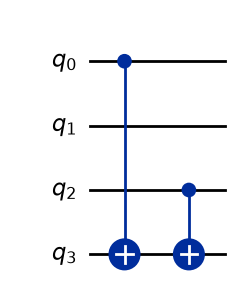

In [2]:
def build_oracle(n: int, secret: int) -> QuantumCircuit:
    # Qubits 0..n-1 are inputs; qubit n is the ancilla that receives f(x) by XOR.
    oracle = QuantumCircuit(n + 1, name=f"U_f[s={secret:0{n}b}]")
    for i in range(n):
        if (secret >> i) & 1:       # bit i of the secret
            oracle.cx(i, n)
    return oracle


oracle = build_oracle(N, SECRET)
oracle.draw("mpl")

## Step 2: The full circuit

We prepare the ancilla in $|-\rangle$ (an `X` then an `H`) and the inputs in $|+\rangle^{\otimes n}$, call the oracle once, apply Hadamards again, and measure only the input qubits. Barriers keep the stages visually separate.

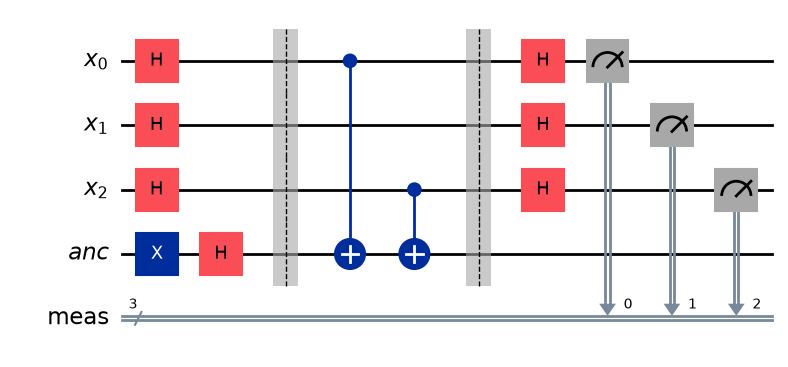

In [3]:
def build_bv_circuit(n: int, secret: int) -> QuantumCircuit:
    inputs = QuantumRegister(n, name="x")
    ancilla = QuantumRegister(1, name="anc")
    bits = ClassicalRegister(n, name="meas")
    circuit = QuantumCircuit(inputs, ancilla, bits, name="bernstein_vazirani")

    # Step 1: |+>^n on the inputs, |-> on the ancilla (so CX kicks back a phase).
    circuit.x(ancilla)
    circuit.h(ancilla)
    circuit.h(inputs)
    circuit.barrier()

    # Step 2: the single oracle call.
    circuit.compose(
        build_oracle(n, secret), qubits=list(inputs) + list(ancilla), inplace=True
    )
    circuit.barrier()

    # Steps 3-4: Hadamards turn the phase pattern into |s>; measure it.
    circuit.h(inputs)
    circuit.measure(inputs, bits)
    return circuit


circuit = build_bv_circuit(N, SECRET)
circuit.draw("mpl")

## Step 3: Interpret the counts

The report function finds the most frequent bitstring and checks it against the hidden string. In an ideal run it appears on every shot; on real hardware noise adds a few wrong strings, but the correct one should still win by a wide margin.

In [4]:
def report(prefix: str, name: str, counts: dict) -> None:
    total = sum(counts.values())
    found, hits = max(counts.items(), key=lambda kv: kv[1])
    status = "correct" if found == expected else "WRONG"
    print(
        f"[{prefix}] most frequent = {found} ({hits / total:.3f}) "
        f"-> s = {found} (expected {expected}: {status})"
    )
    print(f"[{prefix}] counts: {counts}")

## Step 4: Run it

`run_experiments` prints the circuit, runs it on the noiseless Aer simulator, and (if `skip_hardware=False`) also transpiles and submits it to IBM hardware, then calls `report` on each result.

In [5]:
run_experiments({"bernstein_vazirani": circuit}, SETTINGS, report)

Example circuit (bernstein_vazirani):
        ┌───┐      ░            ░ ┌───┐┌─┐      
   x_0: ┤ H ├──────░───■────────░─┤ H ├┤M├──────
        ├───┤      ░   │        ░ ├───┤└╥┘┌─┐   
   x_1: ┤ H ├──────░───┼────────░─┤ H ├─╫─┤M├───
        ├───┤      ░   │        ░ ├───┤ ║ └╥┘┌─┐
   x_2: ┤ H ├──────░───┼────■───░─┤ H ├─╫──╫─┤M├
        ├───┤┌───┐ ░ ┌─┴─┐┌─┴─┐ ░ └───┘ ║  ║ └╥┘
   anc: ┤ X ├┤ H ├─░─┤ X ├┤ X ├─░───────╫──╫──╫─
        └───┘└───┘ ░ └───┘└───┘ ░       ║  ║  ║ 
meas: 3/════════════════════════════════╩══╩══╩═
                                        0  1  2 

--- Aer simulator (noiseless), 4096 shots ---
[aer] most frequent = 101 (1.000) -> s = 101 (expected 101: correct)
[aer] counts: {'101': 4096}


0

## Try it yourself

Change `SECRET` (for example to `0b110`) or `N` (for example to 5) in the Setup cell and rerun everything. The answer should always match the hidden string, after a single oracle call.